In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import warnings
warnings.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ks_2samp

In [2]:
all_feature_train = pd.read_csv("../feature_data/all_feature_train.csv")
all_feature_val = pd.read_csv("../feature_data/all_feature_val.csv")
all_feature_test = pd.read_csv("../feature_data/all_feature_test.csv")

In [3]:
all_feature_val

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,canceled_count,applications_12m,insured_count,approval_rate,avg_application_amount,avg_credit_application_ratio,latest_credit_amount,latest_annuity,latest_days_decision,days_since_last_application
0,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,3.0,7.0,0.0,0.555556,352265.868000,0.951861,675000.000,24246.000,-181.0,181.0
1,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0.0,3.0,0.0,1.000000,76741.714286,0.916226,88632.000,10418.670,-74.0,74.0
2,100018,0,Cash loans,F,N,Y,0,189000.0,773680.5,32778.0,...,0.0,2.0,0.0,1.000000,298363.466250,1.014609,36805.365,4180.365,-188.0,188.0
3,100023,0,Cash loans,F,N,Y,1,90000.0,544491.0,17563.5,...,0.0,2.0,2.0,1.000000,98746.875000,1.080951,239242.500,16822.440,-262.0,262.0
4,100024,0,Revolving loans,M,Y,Y,0,135000.0,427500.0,21375.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46122,456219,0,Cash loans,F,N,Y,1,112500.0,521280.0,31630.5,...,0.0,1.0,0.0,1.000000,69770.250000,1.000000,45000.000,2250.000,-321.0,321.0
46123,456230,0,Cash loans,F,Y,Y,1,292500.0,355536.0,18283.5,...,0.0,1.0,1.0,0.600000,307629.330000,0.982595,292176.000,32594.175,-76.0,76.0
46124,456235,0,Cash loans,M,Y,Y,2,90000.0,1078200.0,31522.5,...,1.0,3.0,1.0,0.800000,69073.998750,0.986228,265500.000,12377.610,-142.0,142.0
46125,456247,0,Cash loans,F,N,Y,0,112500.0,345510.0,17770.5,...,0.0,0.0,1.0,0.800000,61663.500000,0.981527,65295.000,17304.480,-451.0,451.0


In [4]:
df_woe_validation = pd.read_csv("../feature_data/woe_logistics_validation.csv")
df_woe_test = pd.read_csv("../feature_data/woe_logistics_test.csv")

df_woe = pd.read_csv("../feature_data/woe_logistics.csv")
df_woe

,ext_mean,EXT_SOURCE_3,EXT_SOURCE_1,employment_years,credit_utilization,AMT_GOODS_PRICE,active_ratio,age_years,OCCUPATION_TYPE,credit_goods_ratio,...,mean_future_instalments,bad_months_12m_x,NAME_FAMILY_STATUS,total_credit,applications_12m,bad_ratio_all,avg_day_late_12m,late_count_7,SK_ID_CURR,TARGET
0,1.432966,1.216619,1.083050,0.347318,-0.141499,0.345027,-0.368221,0.390646,0.297606,0.091151,...,0.052389,-0.073872,0.230885,-0.131852,-0.065779,-0.047725,-0.192917,-0.047121,100002,1
1,-0.058248,0.160170,0.178621,0.261766,-0.396758,-0.382073,-0.368221,-0.067393,-0.239979,0.000000,...,-0.236809,-0.073872,-0.074798,-0.040703,-0.065779,-0.047725,-0.032824,-0.047121,100003,0
2,-0.866483,-0.892602,0.062084,0.380559,-0.396758,-0.228883,0.000000,-0.199889,0.297606,-0.226147,...,0.052140,-0.073872,0.230885,-0.045248,-0.065779,-0.047725,-0.032824,-0.047121,100004,0
3,0.758194,0.160170,0.062084,-0.138001,-0.396758,-0.103059,0.000000,-0.349789,-0.239979,-0.226147,...,-0.057800,-0.073872,0.230885,-0.028666,-0.065779,-0.047725,0.164660,0.000000,100007,0
4,-0.206739,-0.573697,0.062084,0.099808,0.133992,-0.336651,-0.243636,-0.067393,0.297606,-0.226147,...,0.052140,-0.073872,-0.074798,-0.102800,-0.065779,0.414947,-0.045358,-0.047121,100008,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,-0.346308,0.160170,0.062084,-0.561299,0.259022,0.088992,0.264632,-0.067393,0.184144,0.724179,...,-0.236809,0.264633,-0.008187,0.264633,-0.065779,0.321206,0.065771,0.276201,456248,0
215253,1.432966,0.160170,0.062084,-0.429644,0.259022,0.088992,0.264632,-0.429488,-0.233207,0.103724,...,0.052140,0.264633,-0.333768,0.264633,-0.065779,-0.047725,-0.032824,-0.047121,456252,0
215254,-0.206739,0.822374,-0.927939,-0.724935,0.133992,-0.108693,0.013365,-0.006907,-0.292244,0.091151,...,0.052140,-0.073872,-0.008187,-0.086966,-0.065779,0.321206,-0.032824,-0.047121,456253,0
215255,-0.711590,-0.699244,0.062084,-0.389936,-0.396758,0.345027,0.000000,0.213758,0.297606,0.091151,...,0.052389,-0.073872,-0.074798,0.226301,0.021074,-0.047725,-0.192917,-0.047121,456254,1


In [5]:
len(df_woe.columns)

46

In [6]:
bins_feature = pd.read_csv("../feature_data/bins_feature.csv")
bins_feature

,feature,bins,woe,bad_rate,population,population_pct,min,max,mean,warning
0,ext_mean,"(-0.0009885, 0.235]",1.432966,0.269034,10757,0.049973,0.000011,0.235421,0.269034,NaN
1,ext_mean,"(0.235, 0.304]",0.988018,0.190852,10757,0.049973,0.235432,0.303743,0.190852,NaN
2,ext_mean,"(0.304, 0.35]",0.758194,0.157851,10757,0.049973,0.303750,0.349520,0.157851,NaN
3,ext_mean,"(0.35, 0.384]",0.539512,0.130904,10756,0.049968,0.349522,0.384212,0.130904,NaN
4,ext_mean,"(0.384, 0.414]",0.377922,0.113590,10758,0.049977,0.384214,0.413572,0.113590,NaN
...,...,...,...,...,...,...,...,...,...,...
479,avg_day_late_12m,missing,-0.032824,0.078324,63084,0.293064,NaN,NaN,0.078324,NaN
480,late_count_7,"(-0.001, 1.0]",-0.047121,0.077298,169551,0.787668,0.000000,1.000000,0.077298,NaN
481,late_count_7,"(2.0, 6.0]",0.276201,0.103743,25621,0.119025,2.000000,6.000000,0.103743,NaN
482,late_count_7,"(6.0, 143.0]",0.285693,0.104629,9051,0.042047,7.000000,143.000000,0.104629,NaN


# LOGISTICS DEVELOPMENT

Mục tiêu của Phase là xây dựng một Logistic Regression Scorecard Model có khả năng giải thích, ổn định về mặt thống kê và hợp lý về mặt nghiệp vụ. Thay vì tối ưu ngay hiệu năng dự báo, giai đoạn này tập trung vào việc lựa chọn một tập biến cuối cùng thông qua quá trình đánh giá lặp giữa góc nhìn thống kê và góc nhìn business. Kết quả cuối cùng của sẽ là Final Logistic Model cùng danh sách biến được phê duyệt để chuyển sang bước Validation.


## BaseLine Model

Đây là bước khởi tạo baseline model, với mục tiêu ứng với với model ta sẽ tạo ra được bảng thống kê các chỉ số thống kê cho từng biến.

Ở phần này ta sẽ tập trung trả lời các câu hỏi thống kê với các biến đã được chọn ở phần FineClassing, mô hình có vấn đề gì không. Bao
gòm các công việc sau:
- Kiểm tra p-values
- Hiện tượng đa cộng tuyến (VIF)
- Standard Error thế nào
- Khoảng tin cây
- Các hệ số coefficient của từng biến có hợp lý với input của model.
- Thực hiện việc chọn, loại biến dựa trên các chỉ số thống kê đã tính
 

In [7]:
def prepare_data(df_woe, target_col="TARGET", id_col="SK_ID_CURR"):
    feature = [col for col in df_woe.columns if col not in [target_col,id_col]]
    X = df_woe[feature].copy()
    Y = df_woe[target_col].copy()
    
    X = sm.add_constant(X)
    return X, Y, feature
    
    
def fit_logistics(X: pd.DataFrame, Y: pd.Series, max_iter: int= 200 ):
    model = sm.Logit(Y, X)
    result = model.fit(maxiter= max_iter, disp = False)
    
    return model, result

def extract_coeff(result):
    coef_table = pd.DataFrame({
        "feature": result.params.index,
        "coefficient": result.params.values,
        "std_error": result.bse.values,
        "wald": (result.params / result.bse) **2,
        "p_value": result.pvalues.values,
        "odds_ratio": np.exp(result.params.values)
    })
    
    coef_table = coef_table.sort_values("p_value").reset_index(drop=True)
    
    return coef_table

def extract_predict(result, X, Y , customer_id):
    predict_table = pd.DataFrame({
        "SK_ID_CURR": customer_id,
        "TARGET": Y,
        "PD": result.predict(X)
    })
    return predict_table

def build_model_summary(result, n_features: int):
    """
    Build model summary metrics.
    """

    summary = {
        "n_features": n_features,
        "log_likelihood": result.llf,
        "aic": result.aic,
        "bic": result.bic,
        "pseudo_r2": result.prsquared,
        "n_obs": int(result.nobs)
    }

    return summary


def build_baseline_package(df_woe, target_col="TARGET", id_col="SK_ID_CURR"):

    X, y, feature_names = prepare_data(df_woe, target_col, id_col)

    model, result = fit_logistics(X,y)

    coef_table = extract_coeff(result)

    prediction_table = extract_predict(result, X, y, df_woe[id_col])

    model_summary = build_model_summary(result, len(feature_names))

    package = {
        "X": X,
        "y": y,
        "feature_names": feature_names,
        "model": model,
        "result": result,
        "coef_table": coef_table,
        "prediction_table": prediction_table,
        "model_summary": model_summary,
    }

    return package


In [8]:
baseline_package = build_baseline_package(df_woe)

y = baseline_package["y"]
X = baseline_package["X"]
model = baseline_package["model"]
result = baseline_package["result"]
coeff = baseline_package["coef_table"]
prediction = baseline_package["prediction_table"]
summary = baseline_package["model_summary"]

In [9]:
coeff

,feature,coefficient,std_error,wald,p_value,odds_ratio
0,const,-2.440109,0.009365,67885.104465,0.000000e+00,0.087151
1,ext_mean,0.647933,0.014912,1887.875418,0.000000e+00,1.911585
2,credit_goods_ratio,0.498250,0.030520,266.511872,6.533554e-60,1.645838
3,AMT_GOODS_PRICE,0.549724,0.036856,222.474232,2.610382e-50,1.732774
4,mean_future_instalments,0.801314,0.057340,195.291823,2.224957e-44,2.228467
5,late_payment_rate,0.584471,0.046541,157.710579,3.579984e-36,1.794043
6,EXT_SOURCE_3,0.243466,0.019391,157.641561,3.706483e-36,1.275663
7,credit_utilization,0.484711,0.039258,152.441502,5.073798e-35,1.623706
8,NAME_EDUCATION_TYPE,0.496880,0.042652,135.714861,2.303433e-31,1.643585
9,employment_years,0.360360,0.032003,126.791781,2.063236e-29,1.433845


In [10]:
def check_stable(baseline_package, coeff_threshold= 10, se_threshold= 5):
    coeff = baseline_package["coef_table"]
    result = baseline_package["result"]
    
    review = coeff.copy()
    
    review["large_coeff"] = np.where(review["coefficient"].abs() > coeff_threshold, 1, 0)
    
    review["large_se"] = np.where(review["std_error"].abs() > se_threshold, 1, 0)
    
    review["coef_nan"] = np.where(review["coefficient"].isna(), 1, 0)
    
    review["se_nan"] = np.where(review["std_error"].isna(), 1, 0)
    
    convergence = result.mle_retvals.get(
        "converged",
        None
    )
    summary = {
        "converged": convergence,
        "n_large_coef": int(review["large_coeff"].sum()),
        "n_large_se": int(review["large_se"].sum()) }
    
    return {
        "review": review,
        "summary": summary
    }
    


In [11]:
check_stability = check_stable(baseline_package)
check_stability["summary"]



{'converged': True, 'n_large_coef': 0, 'n_large_se': 0}

In [12]:
check_stability["review"]

,feature,coefficient,std_error,wald,p_value,odds_ratio,large_coeff,large_se,coef_nan,se_nan
0,const,-2.440109,0.009365,67885.104465,0.000000e+00,0.087151,0,0,0,0
1,ext_mean,0.647933,0.014912,1887.875418,0.000000e+00,1.911585,0,0,0,0
2,credit_goods_ratio,0.498250,0.030520,266.511872,6.533554e-60,1.645838,0,0,0,0
3,AMT_GOODS_PRICE,0.549724,0.036856,222.474232,2.610382e-50,1.732774,0,0,0,0
4,mean_future_instalments,0.801314,0.057340,195.291823,2.224957e-44,2.228467,0,0,0,0
5,late_payment_rate,0.584471,0.046541,157.710579,3.579984e-36,1.794043,0,0,0,0
6,EXT_SOURCE_3,0.243466,0.019391,157.641561,3.706483e-36,1.275663,0,0,0,0
7,credit_utilization,0.484711,0.039258,152.441502,5.073798e-35,1.623706,0,0,0,0
8,NAME_EDUCATION_TYPE,0.496880,0.042652,135.714861,2.303433e-31,1.643585,0,0,0,0
9,employment_years,0.360360,0.032003,126.791781,2.063236e-29,1.433845,0,0,0,0


In [13]:
def check_multicoll(baseline_package, vif_threshold: int = 5):
    X = baseline_package["X"].copy()
    
    vif_table = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
    })
    
    vif_table = vif_table.loc[vif_table["feature"] != "const"].reset_index(drop= True)
    
    vif_table["Tolerance"] = 1 / vif_table["VIF"]
    
    vif_table["Flag"] = np.where(vif_table["VIF"] >= vif_threshold, "high vif", "")
    
    summary = {
        "max_vif": vif_table["VIF"].max(),

        "mean_vif": vif_table["VIF"].mean(),

        "n_high_vif": int((vif_table["VIF"] >= vif_threshold).sum())
    }

    return {"review":vif_table, "summary": summary}




In [14]:
multicol = check_multicoll(baseline_package)
multicol["review"]


,feature,VIF,Tolerance,Flag
0,ext_mean,2.204628,0.453591,
1,EXT_SOURCE_3,2.000381,0.499905,
2,EXT_SOURCE_1,1.366855,0.731606,
3,employment_years,1.647742,0.606891,
4,credit_utilization,2.489015,0.401765,
5,AMT_GOODS_PRICE,1.976160,0.506032,
6,active_ratio,3.043235,0.328598,
7,age_years,1.980986,0.504799,
8,OCCUPATION_TYPE,1.406630,0.710919,
9,credit_goods_ratio,1.092203,0.915581,


In [15]:
def statistics_significant(baseline_package, alpha = 0.05):
    result = baseline_package["result"]
    coef_table = baseline_package["coef_table"].copy()
    
    confident_interval = result.conf_int()
    confident_interval.columns = ["ci_lower","ci_uper"]
    confident_interval = confident_interval.reset_index().rename(columns = {"index":"feature"})
    
    review = coef_table.merge(confident_interval, on = "feature", how = "left")
    
    review = (review.loc[review["feature"] != "const"].reset_index(drop=True))
    review["significant"] = review["p_value"] < alpha

    review["Flag"] = np.where(review["significant"],"","not_significant")
    
    summary = {

        "alpha": alpha,

        "n_significant":
            int(review["significant"].sum()),

        "n_not_significant":
            int((~review["significant"]).sum()),

        "max_pvalue":
            review["p_value"].max()
    }
    
    return {
        "review": review,
        "summary": summary}
    



In [16]:
statistics = statistics_significant(baseline_package)
statistics["review"]

,feature,coefficient,std_error,wald,p_value,odds_ratio,ci_lower,ci_uper,significant,Flag
0,ext_mean,0.647933,0.014912,1887.875418,0.000000e+00,1.911585,0.618705,0.677160,True,
1,credit_goods_ratio,0.498250,0.030520,266.511872,6.533554e-60,1.645838,0.438431,0.558068,True,
2,AMT_GOODS_PRICE,0.549724,0.036856,222.474232,2.610382e-50,1.732774,0.477488,0.621959,True,
3,mean_future_instalments,0.801314,0.057340,195.291823,2.224957e-44,2.228467,0.688929,0.913699,True,
4,late_payment_rate,0.584471,0.046541,157.710579,3.579984e-36,1.794043,0.493253,0.675690,True,
5,EXT_SOURCE_3,0.243466,0.019391,157.641561,3.706483e-36,1.275663,0.205460,0.281472,True,
6,credit_utilization,0.484711,0.039258,152.441502,5.073798e-35,1.623706,0.407766,0.561656,True,
7,NAME_EDUCATION_TYPE,0.496880,0.042652,135.714861,2.303433e-31,1.643585,0.413284,0.580476,True,
8,employment_years,0.360360,0.032003,126.791781,2.063236e-29,1.433845,0.297635,0.423084,True,
9,CODE_GENDER,0.494623,0.045118,120.186352,5.758860e-28,1.639880,0.406194,0.583052,True,


In [17]:
def build_warning(row, se_threshold=5, vif_threshold=5, alpha=0.05, coeff_threshold = 10):

    warnings = []
    
    if row["large_coeff"] == 1:
        warnings.append(f"Large coefficient (|Coef|={abs(row['coefficient']):.2f} > {coeff_threshold})")

    if row["large_se"] == 1:
        warnings.append(f"Large standard error (SE={row['std_error']:.2f} > {se_threshold})")

    if row["coef_nan"] == 1:
        warnings.append("Coefficient is NaN")

    if row["se_nan"] == 1:
        warnings.append("Standard error is NaN")

    if row["std_error"] > se_threshold:
        warnings.append(f"Large SE ({row['std_error']:.2f} > {se_threshold})")

    if row["VIF"] > vif_threshold:
        warnings.append(f"High multicollinearity (VIF={row['VIF']:.2f} > {vif_threshold})")

    if row["p_value"] > alpha:
        warnings.append(f"Not statistically significant (p={row['p_value']:.3f})")

    else:
        warnings.append("")
    
    
    return "; ".join(warnings)

def build_baseling_report(baseline_package, check_stability, multicol, statistics):
    report = baseline_package["coef_table"][["feature", "coefficient", "std_error", "p_value"]].copy()
    report = report.loc[report["feature"] != "const"].reset_index(drop = True)
    
    
    vif = multicol["review"][["feature", "VIF"]].copy()
    report = report.merge(vif, on = "feature", how = "left")
    
    stability = check_stability["review"][["feature", "large_coeff", "large_se", "coef_nan", "se_nan"]].copy()
    report = report.merge(stability, on = "feature", how = "left")
    
    sta_sig = statistics["review"][["feature", "Flag"]]
    report = report.merge(sta_sig, on = "feature", how = "left")
    
    report["warning"] =  report.apply(lambda x: build_warning(x),axis=1)
    
    return report.drop(columns=["large_coeff", "large_se","coef_nan","se_nan"])






In [18]:
report = build_baseling_report(baseline_package, check_stability, multicol, statistics)
report 

,feature,coefficient,std_error,p_value,VIF,Flag,warning
0,ext_mean,0.647933,0.014912,0.000000e+00,2.204628,,
1,credit_goods_ratio,0.498250,0.030520,6.533554e-60,1.092203,,
2,AMT_GOODS_PRICE,0.549724,0.036856,2.610382e-50,1.976160,,
3,mean_future_instalments,0.801314,0.057340,2.224957e-44,1.139719,,
4,late_payment_rate,0.584471,0.046541,3.579984e-36,2.182406,,
5,EXT_SOURCE_3,0.243466,0.019391,3.706483e-36,2.000381,,
6,credit_utilization,0.484711,0.039258,5.073798e-35,2.489015,,
7,NAME_EDUCATION_TYPE,0.496880,0.042652,2.303433e-31,1.202028,,
8,employment_years,0.360360,0.032003,2.063236e-29,1.647742,,
9,CODE_GENDER,0.494623,0.045118,5.758860e-28,1.190038,,


In [19]:
def loop_report(df_woe, target_col = "TARGET", id_col = "SK_ID_CURR"):
    baseline_package = build_baseline_package(df_woe, target_col, id_col)
    check_stability = check_stable(baseline_package)
    multicol = check_multicoll(baseline_package, vif_threshold= 5)
    statistics = statistics_significant(baseline_package)
    report = build_baseling_report(baseline_package, check_stability, multicol, statistics)
    
    return report, baseline_package





In [20]:
feature_not_sig = (report[report["Flag"] == "not_significant"]["feature"]).tolist()
feature_not_sig


['bad_ratio_all',
 'active_ratio',
 'closed_loans',
 'avg_day_late',
 'REG_CITY_NOT_WORK_CITY',
 'credit_history_years',
 'latest_annuity']

In [21]:

df_woe_loop_1 = df_woe.copy()
df_woe_loop_1 = df_woe_loop_1[[f for f in df_woe_loop_1.columns if f not in  feature_not_sig]]

df_woe_test_loop_1 = df_woe_test.copy()
df_woe_test_loop_1 = df_woe_test_loop_1[[f for f in df_woe_test_loop_1.columns if f not in  feature_not_sig]]


df_woe_val_loop_1 = df_woe_validation.copy()
df_woe_val_loop_1 = df_woe_val_loop_1[[f for f in df_woe_val_loop_1.columns if f not in  feature_not_sig]]




loop_1, base_line_1 = loop_report(df_woe_loop_1)

In [22]:
loop_1

,feature,coefficient,std_error,p_value,VIF,Flag,warning
0,ext_mean,0.647877,0.014896,0.000000e+00,2.196656,,
1,credit_goods_ratio,0.498829,0.030502,4.068631e-60,1.091102,,
2,AMT_GOODS_PRICE,0.550085,0.036850,2.177714e-50,1.975750,,
3,credit_utilization,0.497312,0.035029,9.559213e-46,2.026610,,
4,late_payment_rate,0.592113,0.042021,4.317286e-45,1.804930,,
5,mean_future_instalments,0.803602,0.057174,7.149258e-45,1.132419,,
6,EXT_SOURCE_3,0.246915,0.019144,4.635719e-38,1.947878,,
7,NAME_EDUCATION_TYPE,0.497487,0.042641,1.884318e-31,1.201506,,
8,employment_years,0.360188,0.031773,8.659412e-30,1.627701,,
9,CODE_GENDER,0.492775,0.044927,5.424748e-28,1.180516,,


In [23]:
base_line_1

{'X':         const  ext_mean  EXT_SOURCE_3  EXT_SOURCE_1  employment_years  \
 0         1.0  1.432966      1.216619      1.083050          0.347318   
 1         1.0 -0.058248      0.160170      0.178621          0.261766   
 2         1.0 -0.866483     -0.892602      0.062084          0.380559   
 3         1.0  0.758194      0.160170      0.062084         -0.138001   
 4         1.0 -0.206739     -0.573697      0.062084          0.099808   
 ...       ...       ...           ...           ...               ...   
 215252    1.0 -0.346308      0.160170      0.062084         -0.561299   
 215253    1.0  1.432966      0.160170      0.062084         -0.429644   
 215254    1.0 -0.206739      0.822374     -0.927939         -0.724935   
 215255    1.0 -0.711590     -0.699244      0.062084         -0.389936   
 215256    1.0 -0.268118      1.216619     -0.927939          0.237422   
 
         credit_utilization  AMT_GOODS_PRICE  age_years  OCCUPATION_TYPE  \
 0                -0.141499  

## Scorecard Construction

Sau khi mô hình Logistic đã được cố định, bước tiếp theo là chuyển đổi mô hình xác suất thành một scorecard có thể sử dụng trong thực tế. Đây là giai đoạn biến các hệ số hồi quy thành hệ thống điểm số mà người dùng cuối có thể diễn giải và áp dụng.

Quá trình này bao gồm việc xác định hệ số scaling (Factor, Offset), tính điểm cho từng bin của từng biến và xây dựng bảng scorecard hoàn chỉnh. Đồng thời, thực hiện phân tích cutoff để minh họa mối quan hệ giữa ngưỡng điểm, tỷ lệ phê duyệt và chất lượng danh mục tín dụng. Trong dự án cá nhân này, phần cutoff chủ yếu nhằm thể hiện hiểu biết về trade-off giữa approval rate và risk thay vì tối ưu theo lợi nhuận kinh doanh.

Input: Final Logistic
Output: Final Scorecard, Score Table, Cutoff Table


Công việc:
- scaling
- factor
- offset
- score contribution
- score table
- score distribution
- cutoff analysis

In [24]:
def calculate_scaling_parameters(baseline_package, base_score=600, pdo=20, pd_target=0.02):
    # 1. Tính Factor
    factor = pdo / np.log(2)
    
    # 2. Tính Base Odds từ PD target
    base_odds = pd_target / (1 - pd_target)
    base_log_odds = np.log(base_odds)
    
    # 3. Tính Offset
    offset = base_score - factor * base_log_odds
    
    # 4. Lấy intercept từ coef_table
    coeff = baseline_package["coef_table"]
    intercept_row = coeff[coeff["feature"] == "const"]
    intercept = intercept_row["coefficient"].values[0]
    
    # 5. Tính Intercept Share (chia đều cho các features, KHÔNG bao gồm const)
    n_features = len(coeff) - 1  # Trừ đi dòng const
    intercept_share = intercept / n_features
    
    # 6. Tính Intercept Score tổng và từng biến
    intercept_score_total = offset - factor * intercept
    intercept_score_per_variable = intercept_score_total / n_features
    
    return {
        # Tham số kinh doanh
        "base_score": base_score,
        "pdo": pdo,
        "pd_target": pd_target,
        "base_odds": base_odds,
        "base_log_odds": base_log_odds,
        
        # Tham số scaling
        "factor": factor,
        "offset": offset,
        
        # Tham số từ model
        "intercept": intercept,
        "n_features": n_features,
        
        # Intercept phân bổ
        "intercept_share": intercept_share,  # intercept / n_features
        "intercept_score_total": intercept_score_total,
        "intercept_score_per_variable": intercept_score_per_variable
    }
    
def caculate_customer_point(baseline_package, df_woe):
    para = calculate_scaling_parameters(baseline_package)
    coeff = baseline_package["coef_table"]
    coeff = coeff.loc[coeff["feature"]!= "const"]
    factor = para["factor"]
    offset = para["offset"]
    intercept = para["intercept"]
    base_point = (offset - factor * intercept) / para["n_features"]
    
    feature_score = pd.DataFrame(index = df_woe.index)
    for _, row in coeff.iterrows():
        feature = row["feature"]
        cofficient = row["coefficient"]
        
        feature_score[feature] = base_point- factor * cofficient * df_woe[feature]
    
    feature_score["credit_score"] = feature_score.sum(axis = 1)
    feature_score.insert(0, "SK_ID_CURR", df_woe["SK_ID_CURR"])
    feature_score.insert(1, "TARGET", df_woe["TARGET"])
    return feature_score

In [25]:
df_woe_score = caculate_customer_point(base_line_1, df_woe_loop_1)

df_woe_score

,SK_ID_CURR,TARGET,ext_mean,credit_goods_ratio,AMT_GOODS_PRICE,credit_utilization,late_payment_rate,mean_future_instalments,EXT_SOURCE_3,NAME_EDUCATION_TYPE,...,EXT_SOURCE_1,NAME_FAMILY_STATUS,DAYS_REGISTRATION,avg_application_amount,applications_12m,late_count_7,bad_months_12m_x,total_credit,ext_std,credit_score
0,100002,1,-5.635905,19.839672,15.675323,23.182040,24.508316,19.936866,12.483850,19.607897,...,17.177983,19.227531,20.609108,21.611235,20.601099,20.729457,20.645324,22.043105,22.096892,743.632777
1,100003,0,22.240493,21.151622,27.215923,26.844866,24.508316,26.642516,20.010498,27.365493,...,20.496273,21.774957,20.609108,22.379001,20.601099,20.729457,20.645324,21.426823,20.639829,815.282982
2,100004,0,37.349462,24.406590,24.784474,26.844866,24.508316,19.942659,27.510941,19.607897,...,20.923840,19.227531,20.609108,18.561053,20.601099,20.729457,20.645324,21.457556,21.999410,808.717282
3,100007,0,6.978118,24.406590,22.787387,26.844866,14.601617,22.491843,20.010498,19.607897,...,20.923840,19.227531,20.609108,21.486328,20.601099,21.151622,20.645324,21.345438,20.266828,768.017473
4,100008,0,25.016348,24.406590,26.494974,19.228914,24.019771,19.942659,25.238912,19.607897,...,20.923840,21.774957,20.759234,21.952587,20.601099,20.729457,20.645324,21.846676,20.903235,805.547941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,456248,0,27.625419,10.728410,19.739134,17.434815,20.022042,26.642516,20.010498,19.607897,...,20.923840,21.219851,23.194366,22.379001,20.601099,23.626154,22.965356,19.362374,20.266828,784.169067
215253,456252,0,-5.635905,19.658711,19.739134,17.434815,16.831679,19.942659,20.010498,19.607897,...,20.923840,23.933095,20.609108,20.541991,20.601099,20.729457,22.965356,19.362374,20.266828,749.992799
215254,456253,0,25.016348,19.839672,22.876814,19.228914,20.022042,19.942659,15.292642,27.365493,...,24.556170,21.219851,21.740316,18.561053,20.601099,20.729457,20.645324,21.739618,20.435567,801.147627
215255,456254,1,34.453926,19.839672,15.675323,26.844866,24.508316,19.936866,26.133366,19.607897,...,20.923840,21.774957,20.609108,21.155220,21.327994,20.729457,20.645324,19.621546,21.718368,802.799491


In [26]:
train_Score = df_woe_score.copy()
validation_score = caculate_customer_point(base_line_1, df_woe_val_loop_1)
test_score = caculate_customer_point(base_line_1, df_woe_test_loop_1)

In [27]:
# ================== CUTOFF ===================================
def build_cutoff_grid(df_woe_score, step):
    score = df_woe_score["credit_score"]
    min_score = np.floor(score.min() / 20) * 20
    max_score = np.ceil(score.max() / 20) * 20

    cutoffs_grid = np.arange(min_score, max_score + 1, 20)
    return cutoffs_grid

def calculate_cutoff_para(df_woe_score,cutoff_threshold, score_col = "credit_score", target_col = "TARGET"):
    approved = df_woe_score[df_woe_score[score_col] >= cutoff_threshold]
    declined = df_woe_score[df_woe_score[score_col] < cutoff_threshold]
    
    total_population = len(df_woe_score)
    total_bad = df_woe_score[target_col].sum()
    n_approved = len(approved)
    n_decline = len(declined)
    
    approval_rate = n_approved / total_population
    
    if n_approved > 0:
        bad_rate_among_approved = approved[target_col].mean()
    else:
        bad_rate_among_approved = np.nan
    
    if n_decline > 0:
        bad_rate_among_decline = declined[target_col].mean()
    else:
        bad_rate_among_decline = np.nan
    if total_bad > 0:
        capture_bad = declined[target_col].sum() / total_bad # số lượng bad rưới ngưỡng so với tổng số bad   
    else:
        capture_bad = np.nan
    
    return {
        "cutoff": cutoff_threshold,
        "approved": n_approved,
        "rejected": n_decline,
        "approval_rate": round(approval_rate * 100, 2),  
        "bad_rate_approved": round(bad_rate_among_approved * 100, 2),
        "bad_rate_declined": round(bad_rate_among_decline * 100, 2),
        "captured_bads": round(capture_bad * 100, 2)
    }
    
def build_cutoff_table(df_woe_score, score_col = "credit_score", target_col = "TARGET", step = 20):
    table = []
    cutoff_threshold_grid = build_cutoff_grid(df_woe_score, step)
    for cutoff_threshold in cutoff_threshold_grid:
        result = calculate_cutoff_para(df_woe_score, cutoff_threshold)
        table.append(result)
    
    cutoff_table = pd.DataFrame(table)
    return cutoff_table

    

In [28]:
build_cutoff_table(validation_score)


,cutoff,approved,rejected,approval_rate,bad_rate_approved,bad_rate_declined,captured_bads
0,680.0,46127,0,100.00,8.07,NaN,0.00
1,700.0,46110,17,99.96,8.06,52.94,0.24
2,720.0,45885,242,99.48,7.86,48.76,3.17
3,740.0,44399,1728,96.25,6.98,36.23,16.81
4,760.0,40103,6024,86.94,5.59,24.60,39.80
5,780.0,31869,14258,69.09,3.98,17.23,65.98
6,800.0,20380,25747,44.18,2.47,12.51,86.49
7,820.0,9027,37100,19.57,1.55,9.66,96.24
8,840.0,2279,43848,4.94,0.79,8.45,99.52
9,860.0,244,45883,0.53,0.41,8.11,99.97


- Ta nhận thấy chỉ số bad_rate_approved giảm dần khi tăng ngưỡng điểm cutoff, đây là điều hợp lý.  

- Tại các ngưỡng 840 trở đi số khách hàng được chấp nhận chiếm khá ít so với population từ đó các chỉ số thống kê không có sức nặng, đủ lí do để không quan tâm tới ngưỡng cutoff này. 

- Trong khoảng từ 760-800 là ngưỡng coi là ổn định, đủ để bắt được khách hàng xấu mà cũng không bỏ lỡ quá nhiều khách hàng tốt.

## Performance Check

Đây không phải là bước validation, mà là một sanity check nhằm xác nhận mô hình hoạt động hợp lý trên chính dữ liệu được sử dụng để xây dựng mô hình.

Mục tiêu của bước này gồm:
- Kiểm tra khả năng xếp hạng rủi ro (rank ordering) của mô hình thông qua phân tích theo decile.
- So sánh Predicted PD với Actual Bad Rate để phát hiện dấu hiệu sai lệch trong việc ước lượng xác suất vỡ nợ.
- Ghi nhận các chỉ số phân biệt (Gini, KS) trên Train set làm mốc tham chiếu cho các bước Validation và OOT phía sau.
- Xác định các red flags nếu mô hình có biểu hiện bất thường trước khi chuyển sang Phase 5.

Input: Final Logistic Model, Final Scorecard, Train Dataset

Output:Decile Performance Table, Calibration Table, Train Gini, Train KS, In-sample Red Flags

In [29]:
def build_decile(score: pd.Series, n_decile = 10):
    decile = pd.qcut(score.rank(method='first', ascending = False), q = n_decile, labels = False) + 1
    return decile

def build_decile_table(df_woe_score, baseline_package, target, n_decile = 10):
    score = df_woe_score["credit_score"]
    predict_pd = baseline_package["prediction_table"]["PD"]
    df = pd.DataFrame({
        "score": score,
        "predict_pd": predict_pd,
        "target": target
    })
    
    df["decile"] = build_decile(score, n_decile = 10)
    
    report = (df.groupby("decile").agg(
        observation = ("target", "count"),
        bads = ("target", "sum"),
        bad_rate = ("target", "mean"),
        average_predicted_pd = ("predict_pd", "mean")
    )).reset_index()
    
    report["bad_rate"] *= 100
    report["average_predicted_pd"] *= 100
    
    return report



In [30]:
decile_table = build_decile_table(df_woe_score,base_line_1, df_woe_score["TARGET"], 10)
decile_table

,decile,observation,bads,bad_rate,average_predicted_pd
0,1,21526,264,1.226424,1.142016
1,2,21526,412,1.913965,1.978480
2,3,21525,528,2.452962,2.744580
3,4,21526,769,3.572424,3.603649
4,5,21526,1038,4.822076,4.641004
5,6,21525,1270,5.900116,5.971651
6,7,21526,1705,7.920654,7.810913
7,8,21525,2335,10.847851,10.517568
8,9,21526,3244,15.070148,15.084028
9,10,21526,5812,26.999907,27.232638


- ta nhận thấy qua từng decile thì bad rate cũng tăng dần, đúng xu hướng mà ta mong muốn.   
- đồng thời chênh lệch giữa bad_rate và average_predicted_pd cũng rất nhỏ, đây là bảng hiệu chỉnh đẹp.
- Cure Shape hợp lý, average_predicted_pd tăng dần qua từng decile (1 tốt nhất -> 10 rủi ro nhất)

In [31]:
def build_roc_curve(baseline_package): 
    predict_pd = baseline_package["prediction_table"]["PD"]
    y = baseline_package["prediction_table"]["TARGET"]
    
    false_positive_rate, true_positive_rate, threshold = roc_curve(y, predict_pd)
    
    auc = roc_auc_score(y, predict_pd)
    gini = round(2 * auc -1, 3)
    return {
        "false_positive_rate": false_positive_rate,
        "true_positive_rate": true_positive_rate,
        "threshold": threshold,
        "auc": auc,
        "gini": gini
    }


def calculate_ks(roc_curve_result):
    true_positive_rate = roc_curve_result["true_positive_rate"]
    false_positive_rate = roc_curve_result["false_positive_rate"]
    threshold = roc_curve_result["threshold"]
    ks = abs(true_positive_rate - false_positive_rate)
    ks_index = np.argmax(ks)
    
    return  {
        "ks": ks[ks_index],
        "ks_threshold": threshold[ks_index],
        "ks_index": ks_index
    }
    
def perfomance_table(baseline_package):
    roc_curve_result = build_roc_curve(baseline_package)
    ks_result = calculate_ks(roc_curve_result)
    
    table = pd.DataFrame({
        "metric": ["ROC_AUC", "gini", "ks", "ks_threshold", "threshold_index"],
        "value": [roc_curve_result["auc"], roc_curve_result["gini"], ks_result["ks"], ks_result["ks_threshold"], int(ks_result["ks_index"])]
   })
    return table

In [32]:
table_check = perfomance_table(base_line_1)
table_check


,metric,value
0,ROC_AUC,0.761018
1,gini,0.522000
2,ks,0.391169
3,ks_threshold,0.078509
4,threshold_index,19454.000000


- gini trong khoảng từ (0.5,0.7) được coi là ổn và khá tốt.   

- AUC có chỉ số cũng đủ tốt đối với model Logistics Regession


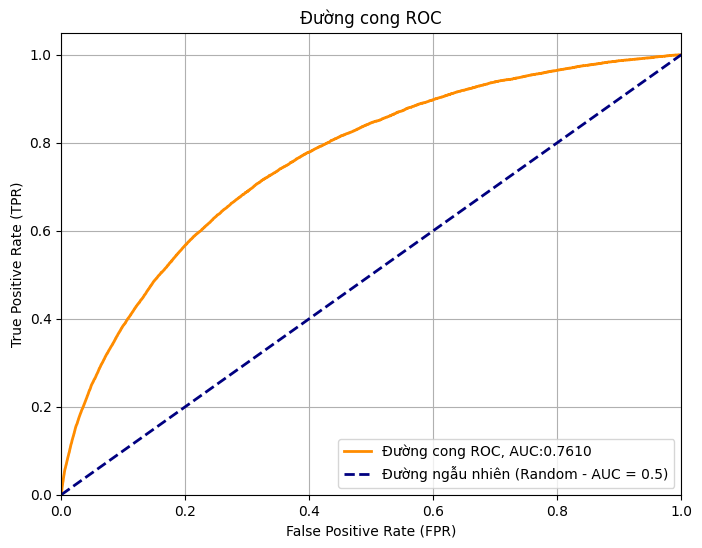

In [33]:
roc_values = build_roc_curve(base_line_1)
tpr, fpr = roc_values["true_positive_rate"], roc_values["false_positive_rate"]
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"Đường cong ROC, AUC:{roc_values["auc"]:.4f}" )
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Đường ngẫu nhiên (Random - AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Đường cong ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


ngướng threshold khá thấp chỉ khoảng > 8% thì khách hàng đã là DF, ta sẽ thử xem phân bố của PD


In [34]:
prediction["PD"].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    215257.000000
mean          0.080727
std           0.079901
min           0.001952
1%            0.006945
5%            0.011820
10%           0.016027
25%           0.027379
50%           0.052459
75%           0.104390
90%           0.186015
95%           0.249910
99%           0.381805
max           0.723124
Name: PD, dtype: float64

75% khách hàng có PD < 10 %, điều này sẽ hợp lý với kết quả, vì đa số điểm PD của khách hàng rất thấp, ta sẽ thử kiểm tra tiếp TPR và FPR tại threshold này


In [35]:
build_roc_curve(base_line_1)["true_positive_rate"][26964], build_roc_curve(base_line_1)["false_positive_rate"][26964]

(np.float64(0.9347413247395984), np.float64(0.6891803112997776))

# Model Validation

## Discriminatory Power: Gini, KS, Curve Shape

In [36]:
def build_val_prediction(baseline_package, df_score: pd.DataFrame, df_woe):
    features = baseline_package["feature_names"]  # ← KHÔNG bao gồm 'const'
    
    X = df_woe[features].copy()
    
    X = sm.add_constant(X)
    
    X = X[baseline_package["X"].columns]
    
    pd_predicted = baseline_package["result"].predict(X)
    
    prediction_table = pd.DataFrame({
        "id_col": df_woe["SK_ID_CURR"].values,
        "target_col": df_woe["TARGET"].values,
        "PD": pd_predicted,
        "credit_score": df_score["credit_score"].values
    })
    
    return prediction_table

In [37]:
test_prediction_table = build_val_prediction(base_line_1, test_score, df_woe_test_loop_1)
val_prediction_table = build_val_prediction(base_line_1, validation_score, df_woe_val_loop_1)
train_prediction_table = build_val_prediction(base_line_1, train_Score, df_woe_loop_1)

In [38]:
test_prediction_table

,id_col,target_col,PD,credit_score
0,100011,0,0.036463,806.770691
1,100014,0,0.063374,790.004364
2,100015,0,0.017099,829.195510
3,100020,0,0.344718,730.828142
4,100022,0,0.025090,817.895879
...,...,...,...,...
46122,456211,0,0.048053,798.458085
46123,456212,0,0.064697,789.367522
46124,456231,0,0.123791,768.761456
46125,456244,0,0.014189,834.664058


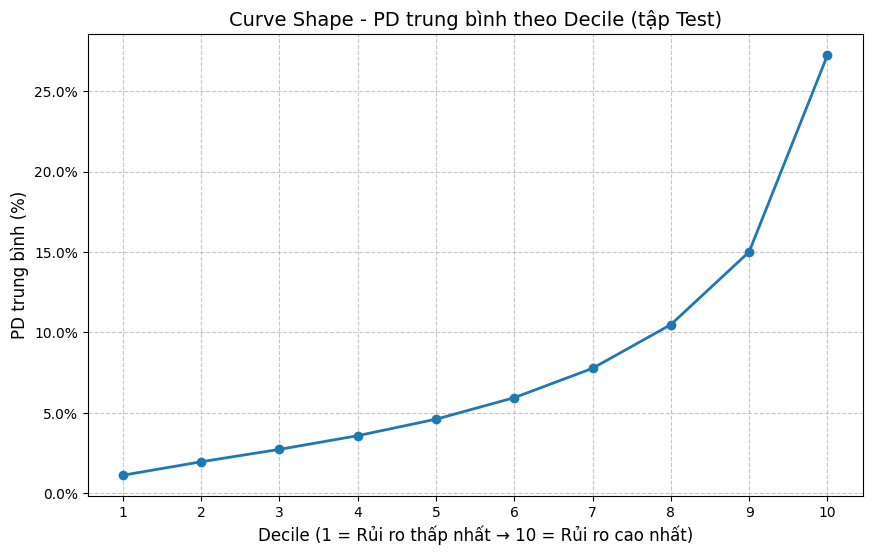

In [39]:
# Curve shape
test_prediction_table['decile'] = pd.qcut(test_prediction_table['credit_score'].rank(method='first', ascending=False), q=10, labels=False) + 1

# 2. Tính PD trung bình theo từng decile
curve_data = test_prediction_table.groupby('decile')['PD'].mean().reset_index()

# 3. Vẽ Curve Shape
plt.figure(figsize=(10, 6))
plt.plot(curve_data['decile'], curve_data['PD'], marker='o', linestyle='-', linewidth=2)

# 4. Tùy chỉnh đồ thị
plt.xlabel('Decile (1 = Rủi ro thấp nhất → 10 = Rủi ro cao nhất)', fontsize=12)
plt.ylabel('PD trung bình (%)', fontsize=12)
plt.title('Curve Shape - PD trung bình theo Decile (tập Test)', fontsize=14)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)

# Định dạng trục Y thành phần trăm
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))

plt.show()

Ta sẽ xem thử phân bố phổ điểm


In [40]:
def plot_credit(prediction_table, n_decile = 10):
    df = prediction_table.copy()
    df["decile"] = pd.qcut(df["credit_score"].rank(method='first', ascending = False), q = n_decile, labels = [1,2,3,4,5,6,7,8,9,10])
    decile_stats = df.groupby("decile").agg(
        count = ("id_col", "count"),
        mean_score = ("credit_score","mean"),
        default_count = ("PD", "sum")
    )
    
    decile_stats["count_pct"] = (decile_stats["count"] / decile_stats["count"].sum()) * 100
    
    fig, axes = plt.subplots(1,2, figsize = (12,8))
    
    ax1 = axes[0]
    sns.histplot(df["credit_score"], bins = 50, kde = True, color = "steelblue", ax = ax1)
    ax1.axvline(df["credit_score"].mean(), color = "red", linestyle = "--", label = f"Mean: {df["credit_score"].mean()}")
    ax1.set_title(f"Phân bố điểm" ,fontsize = 12)
    ax1.set_xlabel(f"Điểm tín dụng")
    ax1.legend()
    ax1.grid()
    
    ax2 = axes[1]
    ax2.bar(range(1,11), (decile_stats["default_count"]/decile_stats["count"].sum())*100 , color = "skyblue")
    ax2.set_title(f'Số lượng KH default theo 10 hạng điểm', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Hạng (1: Tốt nhất → 10: Xấu nhất)')
    ax2.set_ylabel('Tỷ trọng KH (%)')
    ax2.set_xticks(range(1, 11))
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'PHÂN TÍCH DANH MỤC THEO 10 HẠNG ĐIỂM',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
        
    

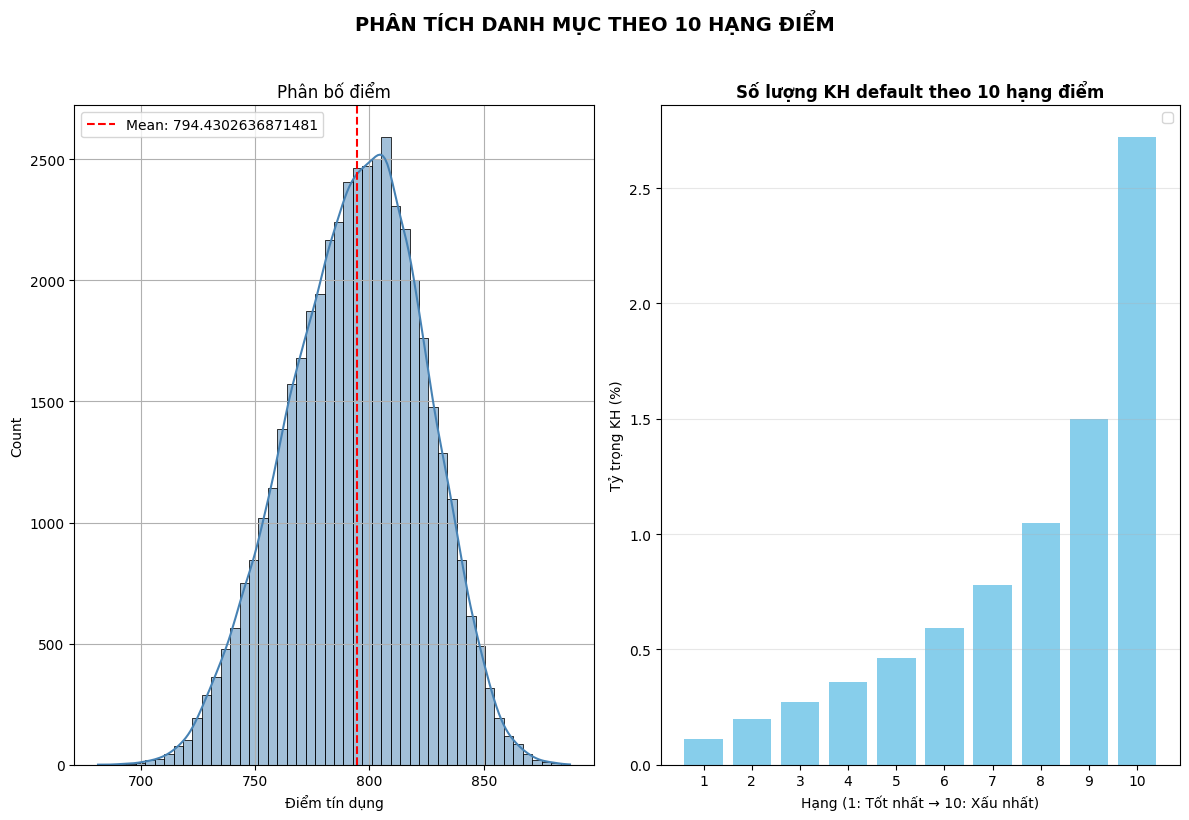

In [41]:
plot_credit(test_prediction_table)

In [42]:
def caculate_gini(prediction_table, target_col = "target_col", id_col = "id_col"):
    false_positive_rate, true_positive_rate, threshold = roc_curve(prediction_table[target_col], prediction_table["PD"])
    auc = roc_auc_score(prediction_table[target_col], prediction_table["PD"])
    
    gini = round(2 * auc - 1,3)
    return {
            "false_positive_rate": false_positive_rate,
            "true_positive_rate": true_positive_rate,
            "threshold": threshold,
            "auc": auc,
            "gini": gini
        }
    
def calculate_ks(result_cal_gini):
    true_positive_rate = result_cal_gini["true_positive_rate"]
    false_positive_rate = result_cal_gini["false_positive_rate"]
    threshold = result_cal_gini["threshold"]
    
    ks = abs(true_positive_rate - false_positive_rate)
    ks_index = np.argmax(ks)
        
    return  {
            "ks": ks[ks_index],
            "ks_threshold": threshold[ks_index],
            "ks_index": ks_index
    }

def build_discriminatory_power(prediction_table_list):
    datasets = {
        "Train": prediction_table_list[0],
        "Validation": prediction_table_list[1],
        "Test": prediction_table_list[2]
    }

    table = []
    for name, prediction_table in datasets.items():    
        result_cal_gini = caculate_gini(prediction_table)
        ks_result = calculate_ks(result_cal_gini)
        table.append({
            "dataset": name,
            "gini": result_cal_gini["gini"],
            "ks": ks_result["ks"],
            "auc": result_cal_gini["auc"]
        })
        
    
    return pd.DataFrame(table)


    

In [43]:
prediction_table_list = [train_prediction_table, val_prediction_table, test_prediction_table]
build_discriminatory_power(prediction_table_list)

,dataset,gini,ks,auc
0,Train,0.522,0.391169,0.761018
1,Validation,0.521,0.387853,0.760514
2,Test,0.520,0.394728,0.759903


Ta có thể thấy chỉ số Gini và KS trên cả 3 tập đều không quá sai lệch với nhau:

- Bản chất là ta đã dùng phép chia dataset stratified giữ cho tỷ lệ Good/Bad nhất quán.    
- Khi đó cà 3 bộ đều chung một phân phối nên việc các chỉ số này gần nhau có thể hiểu được.    
- Và vì chung phân phối nên ta có thể không phải quan tâm nhiều tới việc tỉ lệ bad của từng dataset, hay tập test có nhiều bad hơn tập train và ngược lại.  

In [44]:
def build_deicile_curve(prediction_table, n_decile = 10):
    score = prediction_table["credit_score"]
    predict_pd = prediction_table["PD"]
    target = prediction_table["target_col"]
    decile = pd.qcut(score.rank(method='first', ascending=False), q = n_decile, labels = False) + 1

    df = pd.DataFrame({
        "score": score,
        "PD": predict_pd,
        "target": target
    })
    
    df["decile"] = decile
    
    table = (df.groupby("decile").agg(
        observation = ("target", "count"),
        bad_count = ("target", "sum"),
        bad_rate = ("target", "mean"),
        average_predicted_pd = ("PD", "mean")    
    )).reset_index()
    
    
    table["bad_rate"] *= 100
    table["average_predicted_pd"] *= 100
    
    return table


In [45]:
build_deicile_curve(test_prediction_table)


,decile,observation,bad_count,bad_rate,average_predicted_pd
0,1,4613,51,1.105571,1.132252
1,2,4613,99,2.146109,1.968310
2,3,4612,138,2.992194,2.738336
3,4,4613,157,3.403425,3.588929
4,5,4613,189,4.097117,4.612706
5,6,4612,281,6.092801,5.949338
6,7,4613,374,8.107522,7.774572
7,8,4612,491,10.646141,10.489156
8,9,4613,690,14.957728,15.009024
9,10,4613,1254,27.184045,27.224070


Decile khá đẹp, bad rate đều tăng dần qua từng decile, và tương tự cho dự đoán trung bình PD.  
Tôi cũng đã thực hiện decile cho cả tập train và validation và đều nhận thấy các chỉ số khá giống nhau ở tập test với kết quả như phía trên. Lí do có thể như sau:  

- Đây là việc ta không có thời gian cụ thể để đánh giá POPULATION trong từng thời điểm. vÍ dụ dataset là từ 2015-2020. Để đánh giá đúng đắn, ví dụ ta nên có tập train từ 2015-2018, validation từ 2018-2019 và phần còn lại cho test.
- Tuy nhiên do không có biến thời gian nên ta đã lấy chia ra làm 3 dataet từ thời kỳ 2015-2020. Và vô tình thông tin (data) của 2018-2019 hoặc 2019-2020 đã được trộn lẫn vào tập train (vì việc chia là ngẫu nhiên theo thuật toán, không kiểm soát được) -> đó là lí do các chỉ số giống nhau ở cả 3 test_prediction_table
- Thêm nữa là Gini là chỉ số phụ thuộc vào tỉ lệ bad_rate, và cả 3 dataset đều có bad rate tương đương nhau nên ít nhiều Gini cũng sẽ giống nhau.
- Khi đó các chỉ số như PSI (Population Stability Index) hay MAPE (Mean Absolute Percentage Error) sẽ vô tình "không đúng đắn"  đối với tập train và test ta đang thực hiện
 


## HHI (Herfindahl-Hirschman Index)

In [46]:
test_prediction_table


,id_col,target_col,PD,credit_score,decile
0,100011,0,0.036463,806.770691,4
1,100014,0,0.063374,790.004364,6
2,100015,0,0.017099,829.195510,2
3,100020,0,0.344718,730.828142,10
4,100022,0,0.025090,817.895879,3
...,...,...,...,...,...
46122,456211,0,0.048053,798.458085,5
46123,456212,0,0.064697,789.367522,6
46124,456231,0,0.123791,768.761456,9
46125,456244,0,0.014189,834.664058,1


In [47]:
df_woe_test_loop_1

,ext_mean,EXT_SOURCE_3,EXT_SOURCE_1,employment_years,credit_utilization,AMT_GOODS_PRICE,age_years,OCCUPATION_TYPE,credit_goods_ratio,approval_rate,...,avg_application_amount,mean_future_instalments,bad_months_12m_x,NAME_FAMILY_STATUS,total_credit,applications_12m,avg_day_late_12m,late_count_7,SK_ID_CURR,TARGET
0,-0.268118,-0.892602,-0.488504,-0.429644,-0.396758,-0.403109,-0.349789,-0.233207,-0.195892,-0.166564,...,-0.089234,0.052140,-0.073872,-0.074798,-0.065150,-0.065779,0.164660,0.276201,100011,0
1,0.049935,0.232914,0.178621,0.347318,-0.141499,0.122377,0.390646,-0.239979,-0.226147,-0.166564,...,-0.051540,-0.215096,-0.073872,-0.074798,0.034026,-0.065779,0.058988,-0.047121,100014,0
2,-0.866483,-0.699244,-0.927939,-0.429644,-0.396758,-0.228883,-0.349789,-0.233207,-0.195892,-0.166564,...,0.047229,0.052140,-0.073872,-0.074798,-0.065150,-0.065779,-0.032824,-0.047121,100015,0
3,1.432966,1.216619,0.062084,0.237422,0.229949,0.556322,0.207706,0.354446,0.394118,-0.166564,...,0.295084,-0.279817,-0.073872,-0.074798,-0.045248,-0.065779,-0.016704,-0.047121,100020,0
4,-0.866483,-0.339450,0.062084,-0.724935,-0.240756,0.046943,-0.136343,0.297606,-0.226147,-0.166564,...,0.038803,0.318661,-0.073872,-0.333768,-0.040703,-0.065779,-0.192917,-0.047121,100022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46122,-0.811080,-0.573697,-0.488504,-0.237884,-0.240756,0.556322,0.165568,0.000000,0.394118,0.324409,...,-0.016974,0.318661,-0.073872,-0.074798,-0.028666,0.261026,-0.192917,-0.047121,456211,0
46123,-0.058248,-0.791599,-0.336667,0.380559,-0.294265,0.122377,-0.136343,0.184144,0.103724,-0.166564,...,0.376545,-0.236809,-0.073872,-0.074798,-0.040703,-0.065779,-0.032824,-0.047121,456212,0
46124,0.988018,0.581692,0.062084,-0.429644,-0.240756,-0.403109,-0.429488,-0.233207,0.091151,0.324409,...,-0.066806,0.052140,-0.073872,-0.074798,-0.085394,0.421053,-0.192917,-0.047121,456231,0
46125,-1.160659,0.232914,-1.335344,-0.389936,-0.321023,-0.382073,-0.349789,-0.233207,0.091151,-0.051427,...,-0.178403,0.052389,-0.073872,-0.074798,-0.321447,0.261026,0.058988,0.276201,456244,0


In [48]:
def calculate_hhi(test_prediction_table, all_feature_test, cutoff_threshold = 780):
    df_test = test_prediction_table.copy()
    df = df_test[df_test["credit_score"] >= cutoff_threshold]
    amt_credit_series = all_feature_test[["SK_ID_CURR", "AMT_CREDIT"]].copy()
    df = df.merge(amt_credit_series, left_on = "id_col", right_on = "SK_ID_CURR", how = "inner")
    df["DECILE"] = pd.qcut(df["credit_score"].rank(method='first'), q = 10, labels = False) + 1
    
    total_credit = df["AMT_CREDIT"].sum()
    table = (df.groupby("DECILE").agg(
        observation = ("target_col", "count"),
        bad_count = ("target_col", "sum"),
        bad_rate = ("target_col", "mean"),
        average_predicted_pd = ("PD", "mean"),
        total_amt_per_decile = ("AMT_CREDIT", lambda x: (x.sum() / total_credit)*100)    
            )).reset_index()
    hhi = 0
    for i in range(len(table)):
        hhi += (table["total_amt_per_decile"][i]/100)**2
    return table, hhi
    

- Tôi lấy đại diện nếu ta chọn ngưỡng cutoff là 780, ta cần xem khi áp dụng ngưỡng này, tỉ lệ phân bổ amt_credit của nhóm khách hàng được approved có phân bố đều hay không.  

- Mục đích kiểm tra để đa dạng các nhóm, tránh việc tập trung amt_credit vào một nhóm, nếu tương lai có rủi ro ảnh hưởng trực tiếp tới nhóm này thì rủi ro tổng thể sẽ có thể kiểm soát được hợp lý hơn

In [49]:
hhi_table, hhi = calculate_hhi(test_prediction_table, all_feature_test)
hhi

np.float64(0.10138728155735947)

Chỉ sô HHI tốt

In [50]:
hhi_table


,DECILE,observation,bad_count,bad_rate,average_predicted_pd,total_amt_per_decile
0,1,3197,265,0.082890,0.079399,8.678714
1,2,3196,209,0.065394,0.065724,8.886481
2,3,3196,174,0.054443,0.054969,9.118284
3,4,3196,135,0.042240,0.046096,9.374450
4,5,3196,111,0.034731,0.038723,9.593525
5,6,3196,102,0.031915,0.032531,9.791680
6,7,3196,95,0.029725,0.026755,10.191823
7,8,3196,72,0.022528,0.021470,10.373627
8,9,3196,55,0.017209,0.016114,11.168771
9,10,3197,33,0.010322,0.009876,12.822644


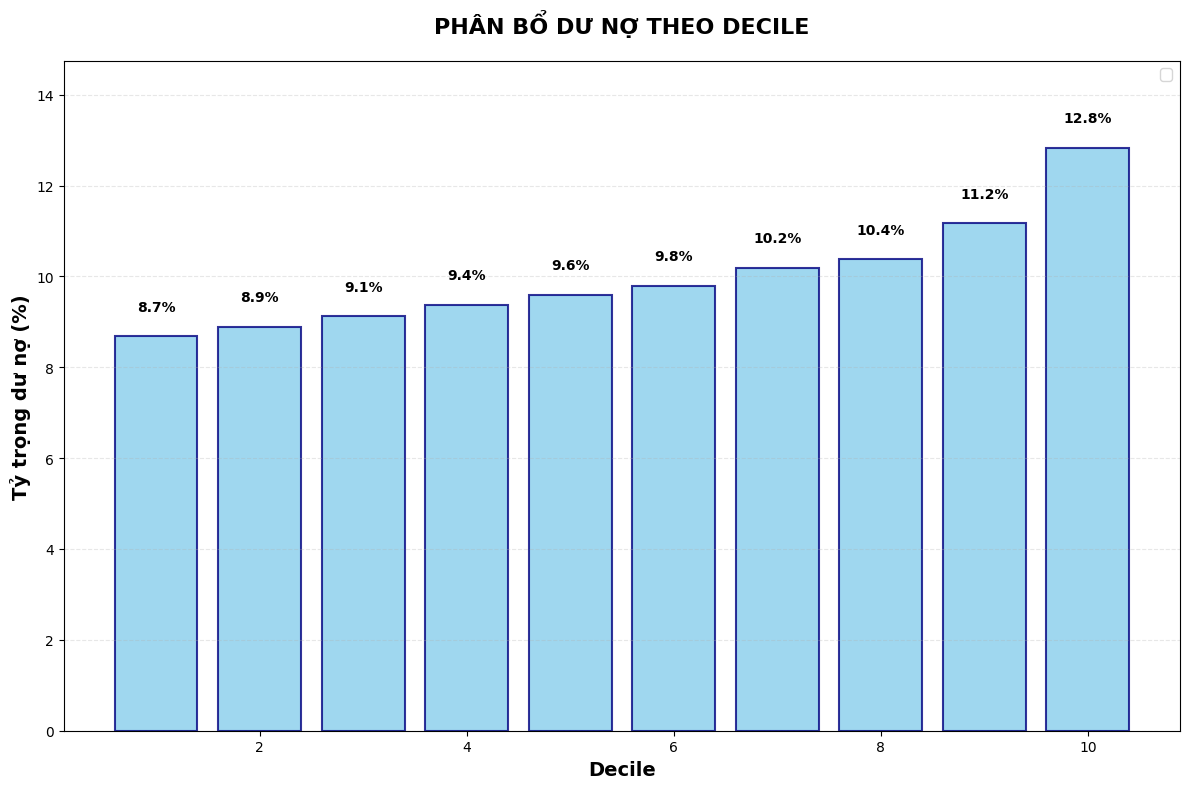

In [51]:
fig, ax = plt.subplots(figsize=(12, 8))

# Vẽ bar chart
bars = ax.bar(
    hhi_table["DECILE"], 
    hhi_table["total_amt_per_decile"],
    color='skyblue',
    edgecolor='navy',
    linewidth=1.5,
    alpha=0.8
)

# Thêm giá trị trên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Tùy chỉnh biểu đồ
ax.set_xlabel("Decile", fontsize=14, fontweight='bold')
ax.set_ylabel("Tỷ trọng dư nợ (%)", fontsize=14, fontweight='bold')
ax.set_title("PHÂN BỔ DƯ NỢ THEO DECILE", fontsize=16, fontweight='bold', pad=20)

# Thêm grid
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Đặt giới hạn trục y
ax.set_ylim(0, max(hhi_table["total_amt_per_decile"]) * 1.15)

# Thêm đường tham chiếu phân bổ đều (10%)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Population Shift Sensitivity Analysis

Sau khi đánh giá discrimination và calibration trên tập Test, bước tiếp theo là kiểm tra khả năng duy trì hiệu năng của mô hình khi đặc điểm khách hàng thay đổi. Do bộ dữ liệu Home Credit không có dữ liệu Out-of-Time, nghiên cứu này xây dựng các kịch bản dịch chuyển population nhằm đánh giá khả năng tổng quát hóa của mô hình dưới những điều kiện hợp lý có thể xảy ra trong tương lai.

model có chịu được việc danh mục tương lai có nhiều khách hàng giống nhóm rủi ro cao hiện tại hơn không.

Các kịch bản được xây dựng dựa trên sự kết hợp của nhiều đặc trưng khách hàng. Cách tiếp cận này phản ánh đúng mục tiêu của model validation: đánh giá khả năng hoạt động của mô hình khi cấu trúc population thay đổi, thay vì chỉ đo lường ảnh hưởng của từng biến độc lập.

Nguyên tắc dược lựa chọn: 
- Mỗi kịch bản phải phản ánh một hướng thay đổi có khả năng xuất hiện trong thực tế thay vì tạo ra các nhóm dữ liệu nhân tạo không có ý nghĩa.
- Mỗi segment cần đủ lớn để Gini ổn định.
- Các scenario nên tác động tới những nhóm biến mà Logistic Regression phụ thuộc nhiều nhất, bao gồm Application, Bureau, Previous Application và Installments.

### Kịch bản I: Danh mục khách hàng dịch chuyển sang nhóm có rủi ro cao hơn.

Nếu trong tương lai danh mục khách hàng dịch chuyển theo hướng có nhiều khách hàng có đặc điểm rủi ro tuong tự so với hiện tại, mô hình có còn duy trì khả năng phân biệt và hiệu chỉnh xác suất vỡ nợ hay không?  
  
Ta sẽ sử dụng các biến:  

- Biến từ tập application:
    - age_years: Khách hàng trẻ thường có lịch sử tín dụng và thu nhập kém ổn định hơn.
    - employment_years: Thời gian làm việc ngắn phản ánh mức độ ổn định nghề nghiệp thấp hơn.
    - AMT_ANNUITY: Khoản trả góp định kỳ lớn phản ánh áp lực thanh toán cao hơn.
    - credit_goods_ratio: Tỷ lệ khoản vay trên giá trị tài sản tài trợ cao thể hiện mức đòn bẩy lớn hơn
- Biến từ tập Application + Previous:
    - applications_12m: Số lần nộp hồ sơ tín dụng gần đây phản ánh nhu cầu tín dụng gia tăng.

In [52]:
scenario_1 = {
    "name": "segment_1",
    "features": {
        "age_years":"negative", # càng tăng thì càng ít rủi ro PD
        "employment_years": "negative",
        "credit_goods_ratio": "positive", #càng tăng thì rủi ro PD càng cao
        "AMT_ANNUITY": "positive",
        "applications_12m": "positive"
    }
}

def caculate_risk_percentile(feature_value: pd.Series, direction: str) -> pd.Series:
    percentile = feature_value.rank(method = "average", pct = True, ascending = True)
    if direction == "negative":
        percentile = 1 - percentile
    
    return percentile

def build_scenario_index(scenario, all_feature: pd.DataFrame, gamma = 3.5):
    risk_table = pd.DataFrame(index = all_feature.index)
    
    for feature, direction in scenario["features"].items():
        df_feature = all_feature[feature].copy()
        if df_feature.isna().any():
            df_feature.fillna(all_feature[feature].median(),inplace = True)
        risk_table[feature] = caculate_risk_percentile(df_feature, direction)
    index_final = risk_table.mean(axis = 1)
    risk_table["final_index"] = index_final
    
    risk_table["weights"] = (risk_table["final_index"])**gamma / ((risk_table["final_index"])**gamma).sum(axis = 0)
    risk_table.insert(0,"SK_ID_CURR", all_feature["SK_ID_CURR"])

    return risk_table
 
        
    

In [53]:
all_feature_test_final = all_feature_test[[f for f in all_feature_test.columns if f not in  feature_not_sig]]

build_scencario_1 = build_scenario_index(scenario_1, all_feature_test_final)
build_scencario_1

,SK_ID_CURR,age_years,employment_years,credit_goods_ratio,AMT_ANNUITY,applications_12m,final_index,weights
0,100011,0.223503,0.499967,0.472175,0.736532,0.199439,0.426323,0.000010
1,100014,0.906855,0.821634,0.176578,0.379301,0.525311,0.561936,0.000025
2,100015,0.205530,0.499967,0.436729,0.089492,0.199439,0.286231,0.000002
3,100020,0.714538,0.658313,0.931418,0.538416,0.525311,0.673599,0.000047
4,100022,0.368645,0.034687,0.176578,0.029657,0.525311,0.226976,0.000001
...,...,...,...,...,...,...,...,...
46122,456211,0.680989,0.197238,0.920123,0.705151,0.940404,0.688781,0.000051
46123,456212,0.349925,0.966928,0.748401,0.463806,0.199439,0.545700,0.000023
46124,456231,0.055922,0.499967,0.618857,0.683829,0.969671,0.565649,0.000026
46125,456244,0.207254,0.082002,0.617513,0.771435,0.940404,0.523721,0.000020


<Axes: >

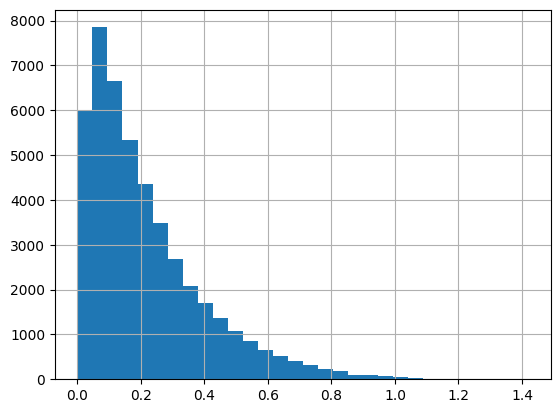

In [54]:
(build_scencario_1["weights"]*10000).hist(bins=30)

- Tôi nhân thêm 10000 để số hiện rõ ràng hơn trong biểu đồ 
- Vì ta chọn gamma = 3.5 theo công thức weights tôi đề cập hàm phía trên, vì weights = final_index / sum(final_index), khi gamma = 3.5 thì khoảng cách giữa chúng càng lớn, final_index và sum(final_index) giảm dần nên luôn kì vọng đồ thị của weights bị lệch trái, số mũ gamma càng lớn càng bị lệch nhiều

In [55]:
def genarate_population_desire(all_feature_test_final, df_woe_test_loop_1, weights: pd.Series, id_col = "SK_ID_CURR",
                               sample_size: int = None, random_state: int = 42):
    if len(all_feature_test_final) != len(df_woe_test_loop_1):
        raise ValueError(
            "raw_test and woe_test must have the same number of rows."
        )    
        
    if sample_size is None:
        sample_size = len(all_feature_test_final)
        
    sample_index = all_feature_test_final.sample(n = sample_size  , replace= True, weights = weights, random_state= random_state).index
    
    new_test_feature = all_feature_test_final.loc[sample_index].reset_index(drop = True)
    
    new_woe_test = df_woe_test_loop_1.loc[sample_index].reset_index(drop = True)
    
    sampling_summary = pd.DataFrame({

        "Original": [len(all_feature_test_final)],

        "Shifted": [len(new_test_feature)],

        "Unique Customers": [new_test_feature[id_col].nunique()],

        "Duplicate Rate": [
            1 -
            new_test_feature[id_col].nunique() / len(new_test_feature)
        ]

    })

    result = {"new_test_feature": new_test_feature,
              "new_woe_test": new_woe_test,
              "sampling_summary": sampling_summary}
    return result

In [56]:
result_scenario_1 = genarate_population_desire(all_feature_test_final, df_woe_test_loop_1,build_scencario_1["weights"] )



In [57]:
def statistic_pouluation(df_test, feature):
    table = []
    for f in feature:
        value_f = df_test[f]
        table.append({
            "feature": f,
            "mean": value_f.mean(),
            "median": value_f.median(),
            "std": value_f.std(),
            "p25": value_f.quantile(0.25),
            "p75": value_f.quantile(0.75)
        })
    table = pd.DataFrame(table)
    table["bad_rate"] = df_test["TARGET"].mean() *100
    return table

def compare_statistic_population(new_test_feature, all_feature_test_final, feature):
    
    origin = statistic_pouluation(all_feature_test_final, feature)
    transform = statistic_pouluation(new_test_feature, feature)
    
    table = origin.merge(transform, on = "feature", how = "inner")
    
    return table 

In [58]:
feature = ['age_years', 'employment_years', 'credit_goods_ratio', 'AMT_ANNUITY', 'applications_12m']
compare_statistic_population(result_scenario_1["new_test_feature"], all_feature_test_final, feature)

,feature,mean_x,median_x,std_x,p25_x,p75_x,bad_rate_x,mean_y,median_y,std_y,p25_y,p75_y,bad_rate_y
0,age_years,43.974687,43.175342,11.987501,34.049315,53.939726,8.073363,38.933261,36.931507,11.074764,29.926027,46.317808,10.627181
1,employment_years,6.551132,4.517808,6.431356,2.120548,8.706849,8.073363,4.206122,2.778082,4.519102,1.350685,5.275342,10.627181
2,credit_goods_ratio,1.123133,1.118800,0.124733,1.000000,1.198000,8.073363,1.162559,1.158398,0.124631,1.079200,1.224398,10.627181
3,AMT_ANNUITY,27130.867699,24889.500000,14424.511640,16542.000000,34719.750000,8.073363,30833.032606,29101.500000,14380.046972,21024.000000,38547.000000,10.627181
4,applications_12m,1.721235,1.000000,2.582247,0.000000,2.000000,8.073363,2.393205,2.000000,2.930210,0.000000,3.000000,10.627181


- Ta thấy rằng các chỉ số cơ bản đã đúng hướng ta muốn khi tạo ra một kịch bản khách hàng rủi ro hơn
- Bad_rate cũng tăng đồng nghĩa với việc kịch bản ta tạo ra đã hợp lý (tăng ~3%)

In [59]:
credit_score_new_test = result_scenario_1["new_woe_test"].merge(test_score[["SK_ID_CURR","credit_score"]], 
                                                                    on = "SK_ID_CURR", how = "inner")
credit_score_new_test

,ext_mean,EXT_SOURCE_3,EXT_SOURCE_1,employment_years,credit_utilization,AMT_GOODS_PRICE,age_years,OCCUPATION_TYPE,credit_goods_ratio,approval_rate,...,mean_future_instalments,bad_months_12m_x,NAME_FAMILY_STATUS,total_credit,applications_12m,avg_day_late_12m,late_count_7,SK_ID_CURR,TARGET,credit_score
0,-0.206739,-0.069373,0.149682,0.380559,0.597392,-0.158740,0.207706,0.297606,0.103724,-0.166564,...,0.052140,0.482710,-0.074798,-0.101090,-0.065779,0.114680,0.276201,232894,0,768.719575
1,0.539512,-0.699244,0.490960,-0.291122,-0.321023,-0.382073,0.165568,0.297606,-0.195892,-0.166564,...,0.052140,-0.073872,-0.074798,-0.085394,-0.065779,-0.192917,0.276201,439074,0,805.105108
2,1.432966,0.581692,0.062084,-0.138001,-0.294265,-0.041488,0.355782,0.000000,-0.226147,-0.166564,...,0.052140,-0.073872,0.230885,-0.037800,-0.065779,-0.032824,-0.047121,360498,0,760.897921
3,0.758194,0.822374,0.327888,0.380559,0.133992,-0.228883,0.437610,-0.239979,-0.226147,0.152785,...,0.052140,-0.073872,0.230885,0.099430,0.132979,0.164660,-0.047121,312697,0,762.741197
4,0.192623,-0.069373,0.149682,0.261766,-0.396758,0.088992,0.313908,0.297606,0.326332,-0.166564,...,0.052140,-0.073872,0.230885,-0.058991,0.021074,0.114680,-0.047121,156232,0,782.425453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46122,-0.268118,-0.339450,0.062084,0.261766,0.133992,0.556322,0.313908,0.184144,-0.226147,-0.166564,...,0.052140,-0.073872,-0.074798,0.226301,0.021074,0.207671,-0.047121,429098,0,776.797259
46123,0.758194,-0.069373,0.062084,0.237422,0.385243,-0.022682,0.437610,-0.259734,0.326332,-0.166564,...,-0.279817,-0.073872,-0.074798,-0.028666,0.021074,-0.192917,-0.047121,407444,0,777.706629
46124,-0.346308,0.160170,0.149682,0.380559,0.259022,-0.382073,-0.006907,0.354446,-0.195892,-0.166564,...,-0.057800,0.264633,-0.074798,0.264633,-0.065779,0.207671,-0.047121,293887,0,775.125599
46125,-0.711590,0.232914,0.062084,-0.237884,-0.018326,0.088992,-0.006907,0.297606,0.326332,0.060590,...,0.052140,-0.073872,-0.008187,0.034026,0.132979,-0.032824,-0.047121,197965,0,767.936481


In [93]:
new_test_build = build_val_prediction(base_line_1, credit_score_new_test, result_scenario_1["new_woe_test"])
new_test_build

,id_col,target_col,PD,credit_score
0,232894,0,0.123949,768.719575
1,439074,0,0.038546,805.105108
2,360498,0,0.156504,760.897921
3,312697,0,0.148254,762.741197
4,156232,0,0.080872,782.425453
...,...,...,...,...
46122,429098,0,0.096607,776.797259
46123,407444,0,0.093891,777.706629
46124,293887,0,0.101783,775.125599
46125,197965,0,0.126926,767.936481


In [61]:
stress_gini = caculate_gini(new_test_build)

print(stress_gini["gini"])
print(stress_gini["auc"])

0.526
0.7630373761133623


In [62]:
merge_1 = build_deicile_curve(new_test_build).merge(build_deicile_curve(test_prediction_table), on = "decile", how = "inner")

merge_1

,decile,observation_x,bad_count_x,bad_rate_x,average_predicted_pd_x,observation_y,bad_count_y,bad_rate_y,average_predicted_pd_y
0,1,4613,55,1.192283,1.331538,4613,51,1.105571,1.132252
1,2,4613,126,2.731411,2.482379,4613,99,2.146109,1.968310
2,3,4612,181,3.924545,3.519648,4612,138,2.992194,2.738336
3,4,4613,204,4.422285,4.696262,4613,157,3.403425,3.588929
4,5,4613,310,6.720139,6.111846,4613,189,4.097117,4.612706
5,6,4612,384,8.326106,7.931852,4612,281,6.092801,5.949338
6,7,4613,466,10.101886,10.370581,4613,374,8.107522,7.774572
7,8,4612,673,14.592368,13.824960,4612,491,10.646141,10.489156
8,9,4613,940,20.377195,19.352006,4613,690,14.957728,15.009024
9,10,4613,1563,33.882506,32.301035,4613,1254,27.184045,27.224070


Bảng hiệu chính (bên x là bảng test mới) cho thấy model làm tốt trên secnario_1


### Kịch bản II: Danh mục khách hàng tập trung nhiều hơn ở vùng điểm trung bình.

Nếu trong tương lai danh mục khách hàng dịch chuyển theo hướng có nhiều khách hàng có đặc điểm rủi ro tuong tự so với hiện tại, mô hình có còn duy trì khả năng phân biệt và hiệu chỉnh xác suất vỡ nợ hay không?  

Ví dụ, sau khi thay đổi chiến lược marketing hoặc chính sách tiền xét duyệt (pre-screening), ngân hàng có thể thu hút chủ yếu những khách hàng có mức rủi ro trung bình. Khi đó, hai nhóm cực tốt và cực xấu giảm tỷ trọng, còn phần lớn khách hàng tập trung quanh vùng quyết định phê duyệt.

Ta sẽ không tập trung vào các biến cụ thể như Scenario_1 mà dựa vào credit_score, mong muốn tạo ra tệp khách có điểm số trung bình.

Scenario 2 đánh giá:

- mức độ nhạy cảm của các chỉ số đánh giá khi cấu trúc score distribution thay đổi;
- khả năng duy trì discrimination của scorecard trong một portfolio có mức độ đồng nhất cao hơn;
- sự ổn định của các chỉ số hiệu chỉnh ở cấp danh mục (portfolio-level calibration metrics)

In [63]:
test_prediction_table.drop(columns = "decile")

,id_col,target_col,PD,credit_score
0,100011,0,0.036463,806.770691
1,100014,0,0.063374,790.004364
2,100015,0,0.017099,829.195510
3,100020,0,0.344718,730.828142
4,100022,0,0.025090,817.895879
...,...,...,...,...
46122,456211,0,0.048053,798.458085
46123,456212,0,0.064697,789.367522
46124,456231,0,0.123791,768.761456
46125,456244,0,0.014189,834.664058


In [86]:
#weight ở đây là list ứng với weight của từng decile (ví dụ chia ra 5 decile thì decile 1,2,3,4,5 lần lượt có weight là weight =[0.05,0.2,0.3,0.4,0.05])
# ứng với mỗi sk_id_curr trong decile sẽ có weight = weigh tương ứng với decile đó / len(decile) đó
def calculate_scen_2(test_prediction_table, df_woe_test_loop_1, weight: list, n_decile=5):
    df = test_prediction_table.copy()
    
    decile = pd.qcut(
        df["credit_score"].rank(method="first", ascending=False),
        q=n_decile,
        labels=False
    ) + 1
    
    df["decile"] = decile
    df["weights"] = 0.0
    
    # Lấy danh sách decile duy nhất (sẽ là [1, 2, 3, 4, 5])
    unique_deciles = sorted(set(df["decile"]))
    
    for i in range(len(unique_deciles)):
        decile_value = unique_deciles[i]  
        total_weight = weight[i]          
        
        mask = df["decile"] == decile_value
        n = mask.sum()
        
        if n > 0:
            df.loc[mask, "weights"] = total_weight / n
    
    sample_index = df_woe_test_loop_1.sample(n = len(df_woe_test_loop_1), replace = True, weights= df["weights"], random_state= 42).index
    new_woe = df_woe_test_loop_1.loc[sample_index].reset_index(drop = True)
    prediction_table_new = df.loc[sample_index].reset_index(drop = True)
    
    return df, new_woe, prediction_table_new # lần lượt là weights của từng khách hàng theo decile, những khách hàng tương ứng với điểm woe (có lặp),
                                                # bảng prediction test mới (có lặp)
    

scen_2_df, scen_2_pred_test, scen_2_woe_test =calculate_scen_2(test_prediction_table,df_woe_test_loop_1 ,weight = [0.1, 0.25, 0.3, 0.25, 0.1])


In [87]:
scen_2_df

,id_col,target_col,PD,credit_score,decile,weights
0,100011,0,0.036463,806.770691,2,0.000027
1,100014,0,0.063374,790.004364,3,0.000033
2,100015,0,0.017099,829.195510,1,0.000011
3,100020,0,0.344718,730.828142,5,0.000011
4,100022,0,0.025090,817.895879,2,0.000027
...,...,...,...,...,...,...
46122,456211,0,0.048053,798.458085,3,0.000033
46123,456212,0,0.064697,789.367522,3,0.000033
46124,456231,0,0.123791,768.761456,5,0.000011
46125,456244,0,0.014189,834.664058,1,0.000011


In [88]:
scen_2_woe_test

,id_col,target_col,PD,credit_score,decile,weights
0,232652,0,0.049332,797.660984,3,0.000033
1,438656,0,0.048084,798.438009,3,0.000033
2,359968,0,0.034591,808.347744,2,0.000027
3,312173,0,0.030834,811.777391,2,0.000027
4,155385,0,0.106554,773.649996,4,0.000027
...,...,...,...,...,...,...
46122,428985,0,0.090977,778.709206,4,0.000027
46123,407389,0,0.075627,784.524306,4,0.000027
46124,292980,0,0.025125,817.854516,2,0.000027
46125,198329,0,0.136671,765.478336,5,0.000011


In [91]:
def cal_statistics_scen_2(scen_2_woe_test, scen_2_df):
    raw = scen_2_df.copy()
    not_raw = scen_2_woe_test.copy()
    
    raw_final = raw.groupby("decile").agg(
    observation=("target_col","size"),
    bad_count=("target_col","sum"),
    bad_rate=("target_col","mean")).reset_index()
    
    not_raw_final = not_raw.groupby("decile").agg(
            observation=("target_col","size"),
            count_pd = ("target_col", "sum"),
            bad_rate = ("target_col","mean")
        ).reset_index()
    
    table_1 = raw_final.merge(not_raw_final, on = "decile", how = "inner")
    
    
    return table_1 
    
cal_statistics_scen_2(scen_2_woe_test, scen_2_df)
    
    

,decile,observation_x,bad_count,bad_rate_x,observation_y,count_pd,bad_rate_y
0,1,9226,150,0.016258,4582,72,0.015714
1,2,9225,295,0.031978,11493,365,0.031758
2,3,9225,470,0.050949,13681,647,0.047292
3,4,9225,865,0.093767,11706,1102,0.094140
4,5,9226,1944,0.210709,4665,943,0.202144


- Bên trái là bảng thống kê của prediction_test gốc, bên phải là của trên kịch bản thứ 2
- Vì ta lặp những khách hàng điểm tầm trung nhiều hơn nên tại 2 đầu sẽ có sự chênh lệch TARGET.
- Bảng trên được tạo ra để xem bad_rate có thay đổi hay không, kịch bản thứ 2 này đã chỉ ra điều đó.
- Ta kì vọng bad sẽ giảm ở vùng giữa và đầu (vì ta lặp ở khoảng Q2-Q4 nhiều hơn, từ đó nhiều khách hàng điểm tầm trung hơn), qua bảng trên thì đúng là như vậy

In [92]:
caculate_gini(scen_2_woe_test)

{'false_positive_rate': array([0.00000000e+00, 2.32568957e-05, 4.65137913e-05, ...,
        9.99930229e-01, 9.99953486e-01, 1.00000000e+00], shape=(17370,)),
 'true_positive_rate': array([0., 0., 0., ..., 1., 1., 1.], shape=(17370,)),
 'threshold': array([       inf, 0.66086835, 0.65609713, ..., 0.00309705, 0.00302344,
        0.00228591], shape=(17370,)),
 'auc': 0.7151457585985367,
 'gini': 0.43}

In [103]:
scen_2_woe_test.describe()

,id_col,target_col,PD,credit_score,decile,weights
count,46127.000000,46127.000000,46127.000000,46127.000000,46127.000000,46127.000000
mean,277237.016693,0.067834,0.069539,794.795422,3.008216,0.000025
std,102643.453655,0.251464,0.060176,22.707854,1.142266,0.000008
min,100011.000000,0.000000,0.002286,693.043847,1.000000,0.000011
25%,188347.500000,0.000000,0.033431,780.873224,2.000000,0.000027
50%,276961.000000,0.000000,0.052425,795.812360,3.000000,0.000027
75%,365634.500000,0.000000,0.084961,809.366141,4.000000,0.000033
max,456244.000000,1.000000,0.660868,887.688444,5.000000,0.000033


In [104]:
scen_2_df.describe()

,id_col,target_col,PD,credit_score,decile,weights
count,46127.000000,46127.000000,46127.000000,46127.000000,46127.00000,46127.000000
mean,277489.443276,0.080734,0.080488,794.430264,3.00000,0.000022
std,102816.394456,0.272429,0.079863,29.158902,1.41426,0.000009
min,100011.000000,0.000000,0.002286,681.425693,1.00000,0.000011
25%,188347.500000,0.000000,0.027311,774.353594,2.00000,0.000011
50%,277230.000000,0.000000,0.052160,795.966732,3.00000,0.000027
75%,366350.500000,0.000000,0.104255,815.382493,4.00000,0.000027
max,456249.000000,1.000000,0.744563,887.688444,5.00000,0.000033


In [116]:
print(sum(scen_2_woe_test["credit_score"] > 810))
print(sum(scen_2_df["credit_score"] > 810))

11053
14466


In [100]:
build_deicile_curve(scen_2_woe_test, n_decile= 10)

,decile,observation,bad_count,bad_rate,average_predicted_pd
0,1,4613,72,1.560806,1.555544
1,2,4613,127,2.753089,2.666893
2,3,4612,143,3.100607,3.340801
3,4,4613,173,3.750271,4.058859
4,5,4613,202,4.378929,4.823894
5,6,4612,234,5.073721,5.727430
6,7,4613,298,6.460004,6.856950
7,8,4612,430,9.323504,8.520547
8,9,4613,513,11.120746,10.897286
9,10,4613,937,20.312161,21.090541


In [ ]:
def curve_bad_scen_2(scen_2_woe_test):
    df = scen_2_woe_test.copy()
    
    table = df.groupby("decile").agg(
        observation = ("id_col","count"),
        bad_count = ("target_col", "sum"),
        bad_rate = ("target_col","mean"),
        average_predicted_pd = ("PD", "mean")
    )
    
    return pd.DataFrame(table)

curve_bad_scen_2(scen_2_woe_test)


,observation,bad_count,bad_rate,average_predicted_pd
decile,,,,
1,4582,72,0.015714,0.015501
2,11493,365,0.031758,0.031703
3,13681,647,0.047292,0.052792
4,11706,1102,0.094140,0.091464
5,4665,943,0.202144,0.209935


- việc ta tạo các kịch bản phía trên không tạo ra khách hàng mới, mà chỉ lặp lại những khách hàng đã biết và tạo ra một phân bố với mức độ tập trung khác nhau.
- Khi đó bad_rate trong từng vùng decile sẽ vẫn giữ ổn định vì chỉ lặp lại những khách hàng đã biết, chỉ khách tỉ trọng.
- Cái ta quan tâm là liệu trong Calibration, sẽ có những khách hàng là bad (xác xuất vỡ nợ (PD) thực tế có thể là 30%) nhưng model lại nhận diện PD chỉ 8%, khi đó nếu model lặp lại những khách hàng nhưu vậy thì Calibraion có thể sẽ bị nhiễu và cho ra bảng kết quả k hợp lý.
- AUC giảm theo tôi có những nguyên nhân sau:
    - AUC trả lời câu hỏi rằng xác suất khách hàng xấu có lên hơn xác suất khách hàng good hay không, nghĩa là model có dự đoán đúng hay không
    - Ta đã duplicate khách hàng điểm số tầm trung lên và vô tình có những khách hàng model dự đoán nhầm có thể tăng lên khi đó phân biệt bad good sẽ khó khăn hơn
    - Từ đó AUC sẽ giảm.
    - Vì phương sai credit_score giảm từ 29-22 nên điểm số được co lại, sẽ có ít số khách hàng tốt, ít khách hàng xấu hơn, từ đó việc phân biệt các cặp bad-good sẽ giảm vì phần lớn bây giờ nằm ở vùng điểm bình thường, các cặp sẽ không rõ ràng như khi điểm lớn hơn hẳn hoặc điểm nhỏ hơn hản
  

Tuy nhiên bảng hiệu chỉnh (calibraion) lại khá đẹp, model vẫn logic trong từng vùng rủi ro